In [33]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [45]:
df = pd.read_csv("archive/retail_sales_dataset.csv", encoding="utf-8")

In [46]:
features = ["Gender","Age","Product Category","Quantity","Price per Unit", "Total Amount"]
df = df[features]

In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [48]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[['Product Category']])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Product Category']),
    index=df.index
)

df = df.drop(columns=['Product Category'])
df = pd.concat([df, encoded_df], axis=1)

In [49]:
df.head()

,Gender,Age,Quantity,Price per Unit,Total Amount,Product Category_Beauty,Product Category_Clothing,Product Category_Electronics
0,1,34,3,50,150,1.0,0.0,0.0
1,0,26,2,500,1000,0.0,1.0,0.0
2,1,50,1,30,30,0.0,0.0,1.0
3,1,37,1,500,500,0.0,1.0,0.0
4,1,30,2,50,100,1.0,0.0,0.0


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [55]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertias.append(km.inertia_)

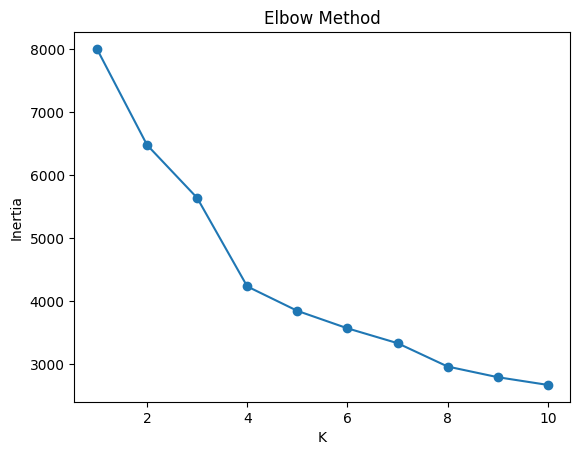

In [56]:
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [60]:
best_model = KMeans(n_clusters=5,random_state=42)
best_model.fit(df_scaled)
df_scaled['cluster'] = best_model.labels_

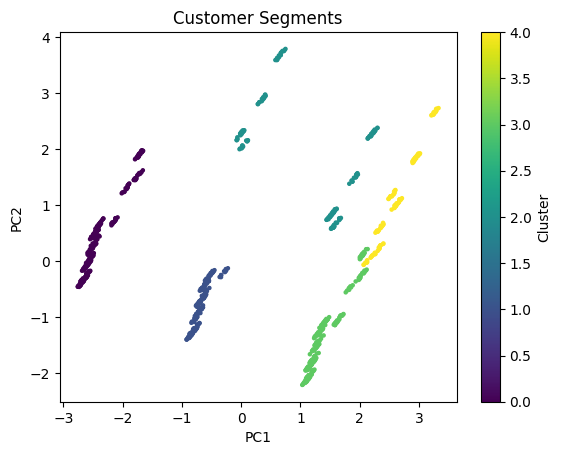

In [61]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df_scaled["cluster"], cmap="viridis", s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments")
plt.colorbar(label="Cluster")
plt.show()

In [63]:
df_scaled["cluster"] = df_scaled["cluster"]
print(df.groupby("cluster").mean())

           Gender        Age  Quantity  Price per Unit  Total Amount  \
cluster                                                                
0        0.522648  42.651568  2.358885      115.592334    219.790941   
1        0.459184  41.045918  2.397959       49.005102     99.056122   
2        0.470149  40.522388  3.350746      440.298507   1436.567164   
3        0.500000  41.643382  2.268382      114.742647    209.209559   
4        0.459459  39.180180  2.711712      422.522523   1118.018018   

         Product Category_Beauty  Product Category_Clothing  \
cluster                                                       
0                            0.0                   1.000000   
1                            1.0                   0.000000   
2                            0.0                   0.477612   
3                            0.0                   0.000000   
4                            1.0                   0.000000   

         Product Category_Electronics  
cluster      